In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, cross_val_score
from imblearn.over_sampling import SMOTE 

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.metrics import accuracy_score, precision_score, f1_score, r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

from sklearn.ensemble import BaggingRegressor, BaggingClassifier, GradientBoostingRegressor, GradientBoostingClassifier, StackingRegressor, StackingClassifier

from sklearn.linear_model import ElasticNet, Ridge, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree

from xgboost import XGBClassifier, XGBRegressor

from lightgbm import LGBMClassifier, LGBMRegressor

from catboost import CatBoostClassifier, CatBoostRegressor

RANDOM_STATE = 42

class_cv = StratifiedKFold(5, shuffle = True, random_state = RANDOM_STATE)
reg_cv = KFold(5, shuffle = True, random_state = RANDOM_STATE)

In [71]:
def print_metrics(true, pred, task_type):
    if task_type == "reg":
        print(f"R2: {r2_score(true, pred)}")
        print(f"MSE: {mean_squared_error(true, pred)}")
        print(f"MAE: {mean_absolute_error(true, pred)}")
        print(f"MAPE: {mean_absolute_percentage_error(true, pred)}")
        
        return
    elif task_type == "class":
        print(f"Accuracy: {accuracy_score(true, pred)}")
        print(f"Precision: {precision_score(true, pred, average = 'weighted')}")
        print(f"F1 score: {f1_score(true, pred, average = 'weighted')}")

        return

**Загрузка датасетов**

In [ ]:
class_df = pd.read_csv("../csv/cl_finished.csv", sep = ";")
X_class = class_df.drop(columns = "Diabetes_012")
y_class = class_df["Diabetes_012"]

X_class_train, X_class_test, y_class_train, y_class_test = train_test_split(X_class, y_class, test_size = 0.3, stratify = y_class, random_state = RANDOM_STATE)

sm = SMOTE(random_state=RANDOM_STATE)
X_class_train_resampled, y_class_train_resampled = sm.fit_resample(X_class_train, y_class_train)

In [73]:
regress_df = pd.read_csv("../csv/winequality_finished.csv", sep = ";")
X_reg = regress_df.drop(columns = "quality")
y_reg = regress_df["quality"]

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size = 0.3, random_state = RANDOM_STATE)

**Модели решающих деревьев**

In [ ]:

def objective_trees(trial, model_type):
    if model_type == "classification":
        max_depth = trial.suggest_int("max_depth", 2, 64)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 32)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 32)

        criterion = trial.suggest_categorical("criterion", ["gini", "entropy", "log_loss"])

        model = DecisionTreeClassifier(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)
        
        score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()
        
        return score

    
    if model_type == "regression":

        max_depth = trial.suggest_int("max_depth", 2, 64)
        min_samples_split = trial.suggest_int("min_samples_split", 2, 16)
        min_samples_leaf = trial.suggest_int("min_samples_leaf", 2, 16)

        criterion = trial.suggest_categorical("criterion", ['squared_error', 'friedman_mse', 'absolute_error', 'poisson'])

        model = DecisionTreeRegressor(max_depth = max_depth, min_samples_split = min_samples_split, 
                                            min_samples_leaf = min_samples_leaf, criterion = criterion, random_state = RANDOM_STATE)

        score = cross_val_score(model, X_reg_train, y_reg_train, cv = reg_cv, scoring = "neg_mean_squared_error").mean()

        return score

In [75]:
study_class = optuna.create_study(direction = "maximize")
study_class.optimize(lambda trial: objective_trees(trial, "classification"), n_trials = 25)

best_class_tree_model = DecisionTreeClassifier(**study_class.best_params, random_state = RANDOM_STATE)
best_class_tree_model.fit(X_class_train, y_class_train)

pred = best_class_tree_model.predict(X_class_test)
print_metrics(y_class_test, pred, "class")

Accuracy: 0.8334953216798433
Precision: 0.7849527680528444
F1 score: 0.7820226441182052


C:\Users\Chaizee\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


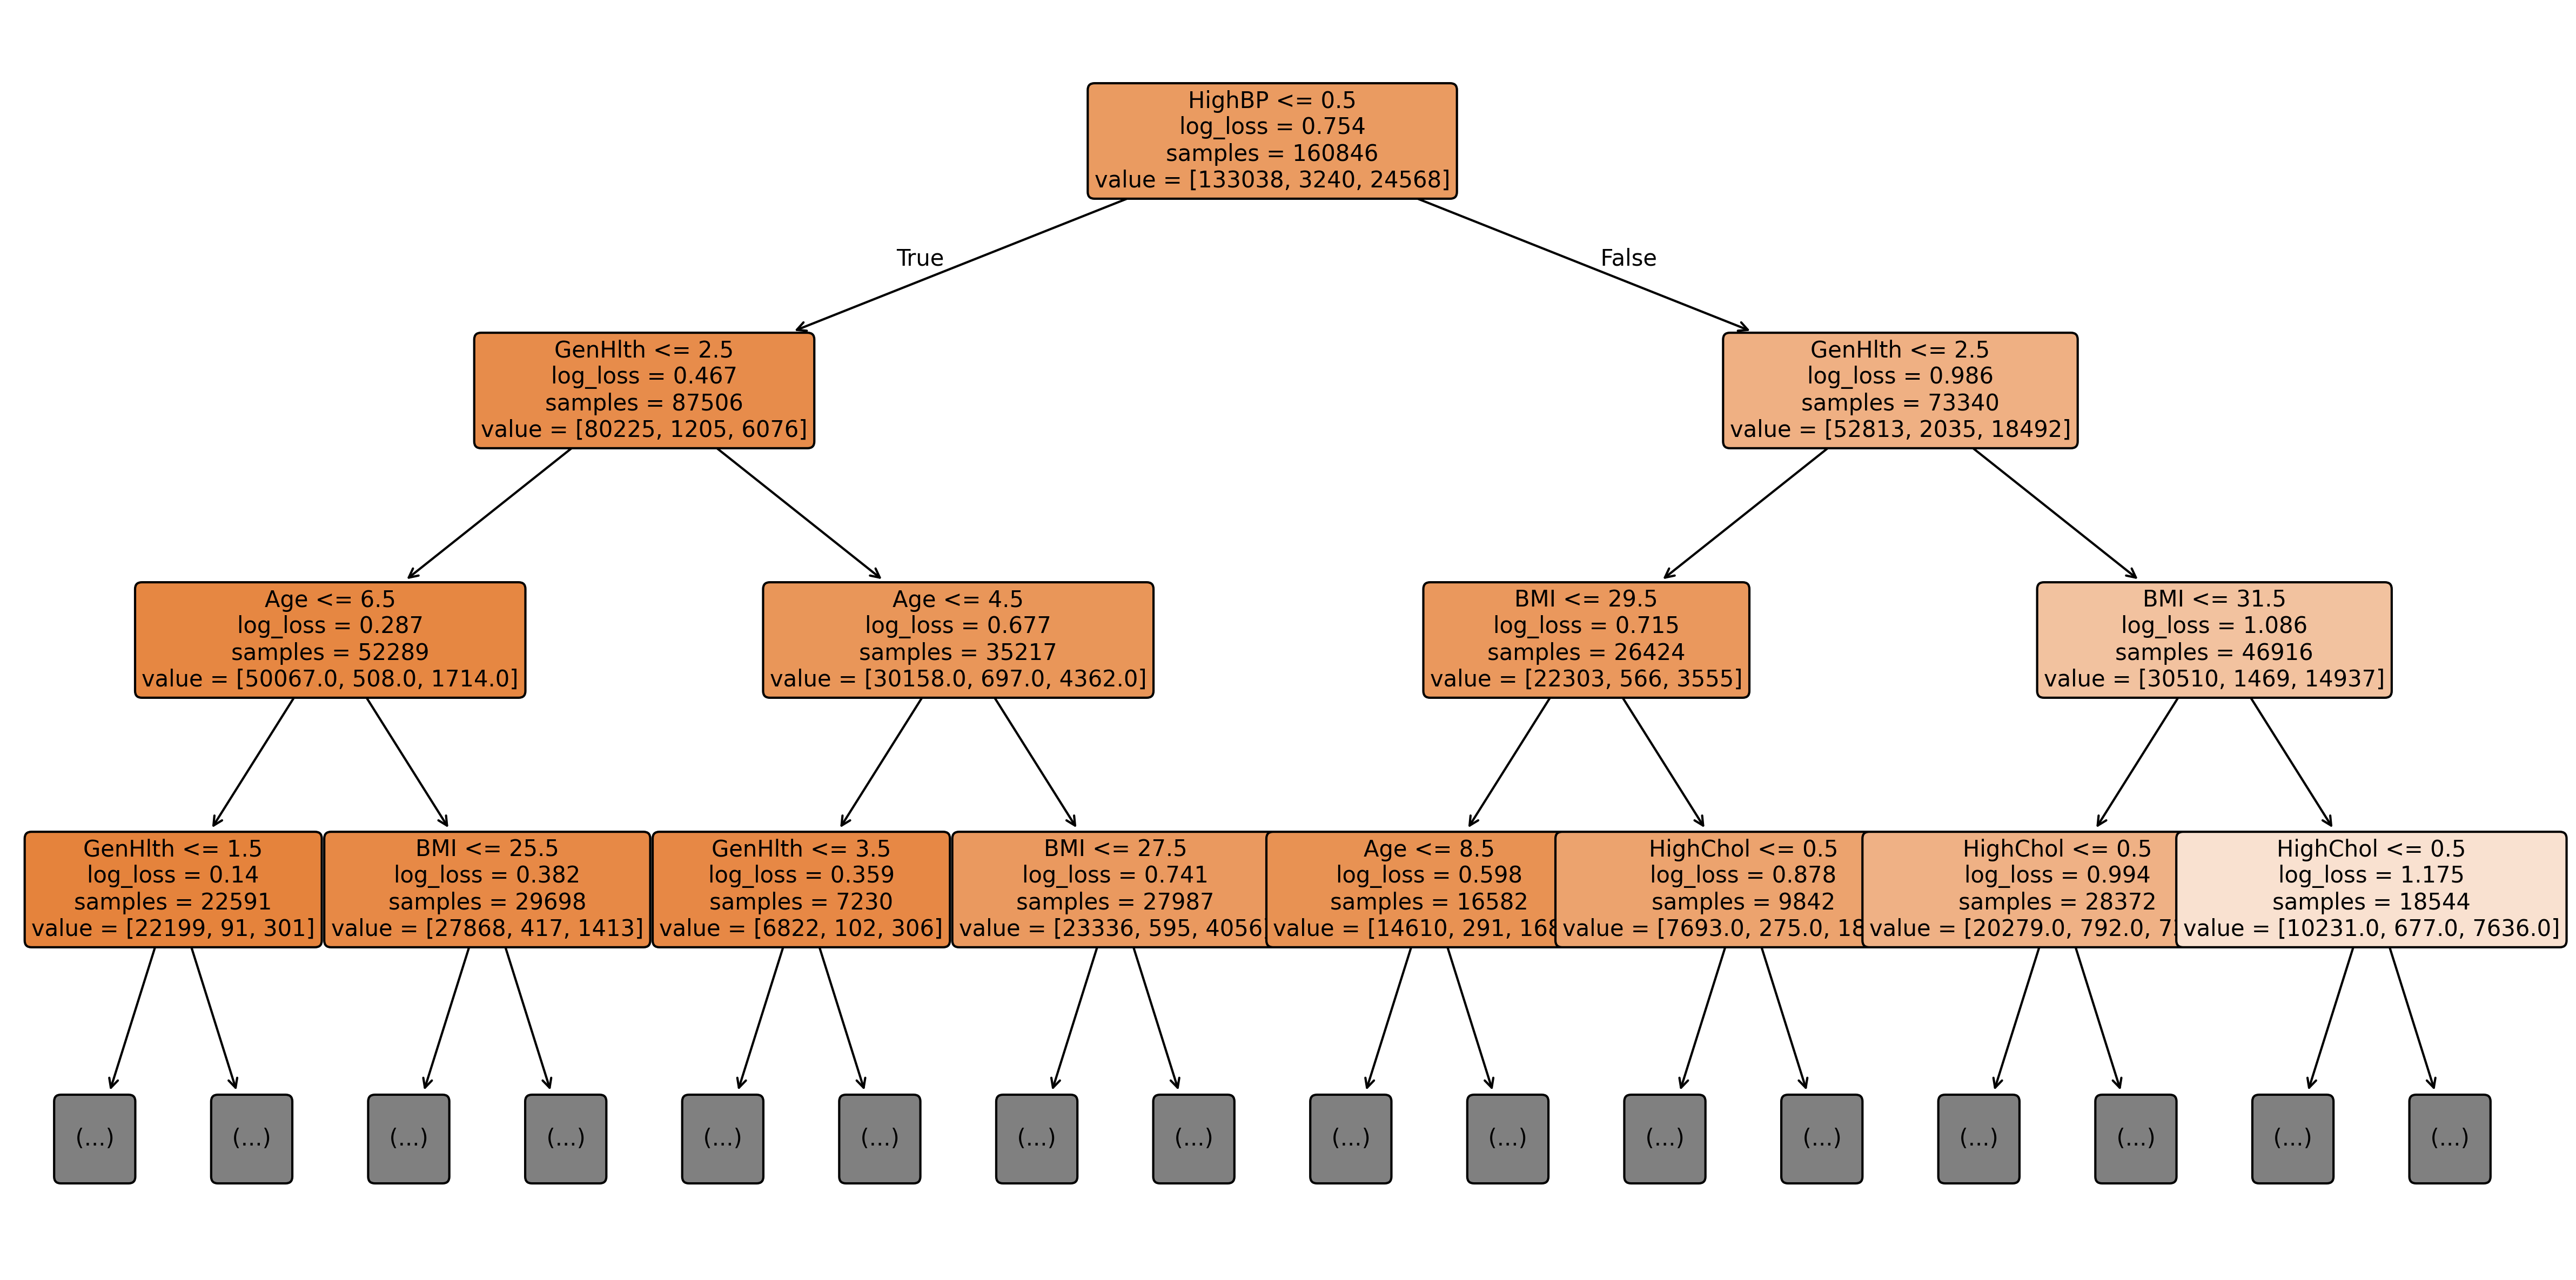

In [76]:
plt.figure(figsize=(20, 10), dpi=300)

plot_tree(
    best_class_tree_model,
    max_depth=3,
    feature_names=X_class.columns,
    filled=True,
    rounded=True,
    fontsize=10,
)

plt.show()

In [77]:
study_reg = optuna.create_study(direction = "maximize")
study_reg.optimize(lambda trial: objective_trees(trial, "regression"), n_trials = 100)

best_reg_tree_model = DecisionTreeRegressor(**study_reg.best_params, random_state = RANDOM_STATE)
best_reg_tree_model.fit(X_reg_train, y_reg_train)

pred_reg = best_reg_tree_model.predict(X_reg_test)
print_metrics(y_reg_test, pred_reg, "reg")

R2: 0.2851411119542602
MSE: 0.5215896202739858
MAE: 0.5616695829009875
MAPE: 0.10077939517312079


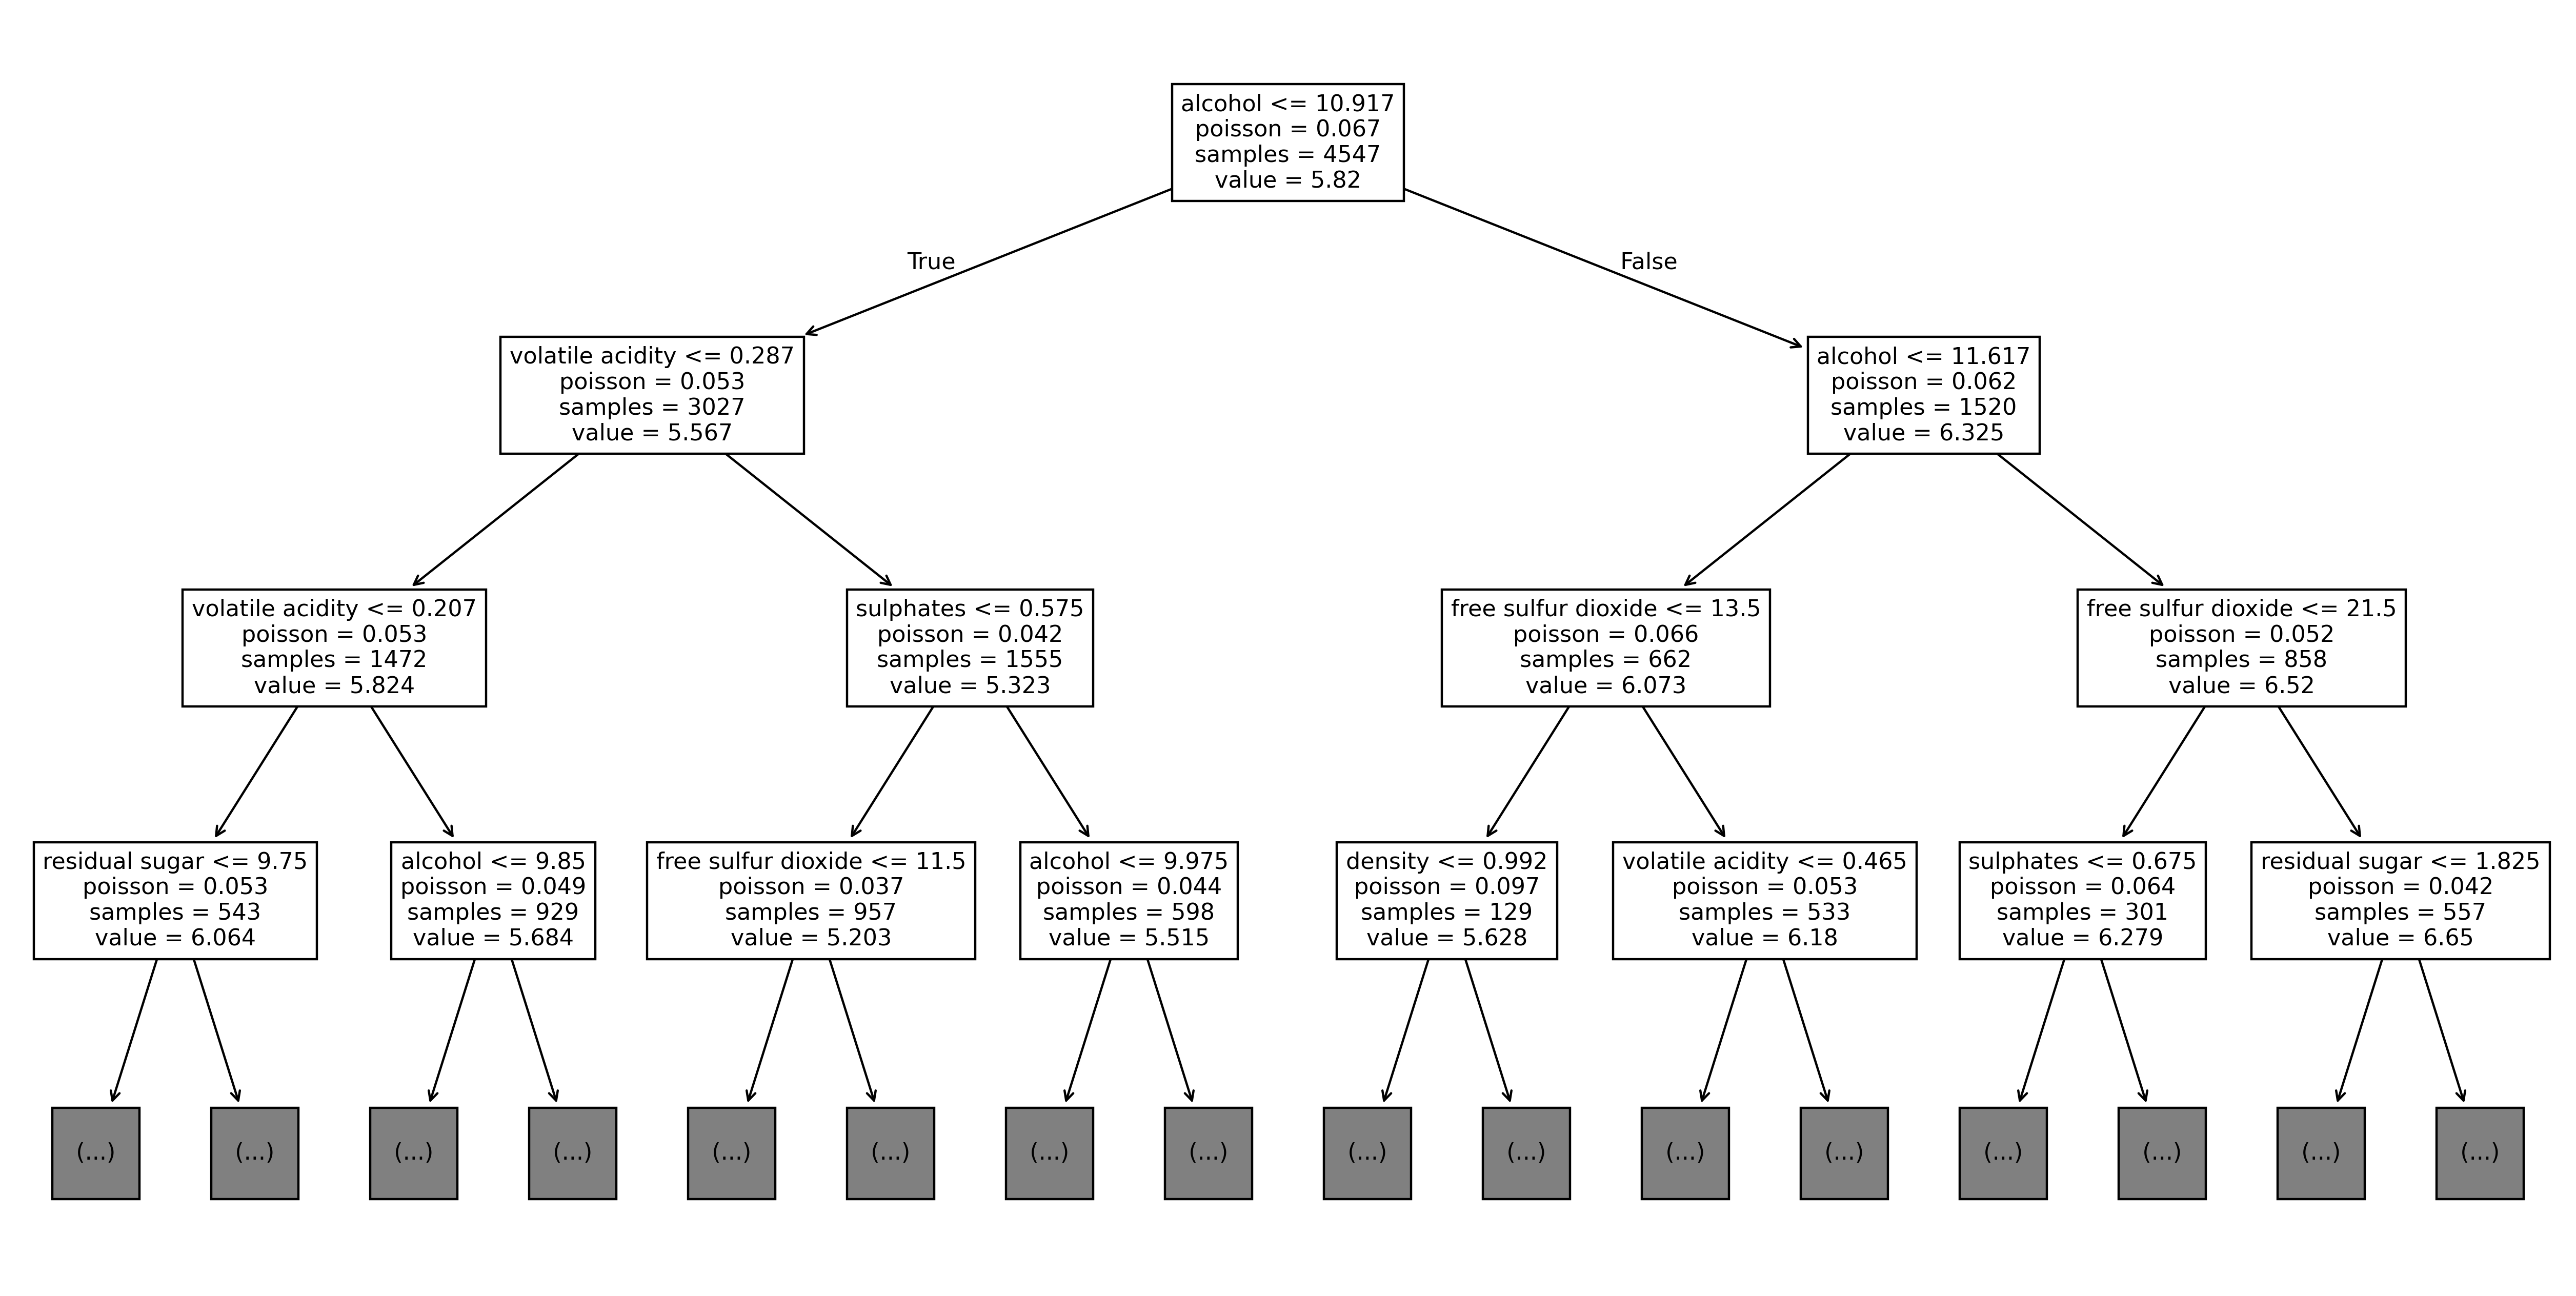

In [78]:
plt.figure(figsize = (20, 10), dpi = 320)

plot_tree(
    best_reg_tree_model,
    max_depth = 3,
    feature_names = X_reg.columns,
    fontsize = 10
)

plt.show()

**Модели ансамблей**

In [79]:
def objective_ensembles(trial, model_type):
    if model_type in ["BaggingRegressor", "BaggingClassifier"]:
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 10, 50),
            "max_samples": trial.suggest_float("max_samples", 0.5, 1.0),
            "max_features": trial.suggest_float("max_features", 0.5, 1.0),
            "bootstrap": trial.suggest_categorical("bootstrap", [True, False]),
        }

        if model_type == "BaggingRegressor":
            base_tree = DecisionTreeRegressor(**study_reg.best_params, random_state = RANDOM_STATE)
            
            model = BaggingRegressor(estimator = base_tree, **params, random_state = RANDOM_STATE)
            score = cross_val_score(model, X_reg_train, y_reg_train, cv=reg_cv, scoring="neg_mean_squared_error").mean()

        elif model_type == "BaggingClassifier":
            base_tree = DecisionTreeClassifier(**study_class.best_params, random_state=RANDOM_STATE)

            model = BaggingClassifier(estimator=base_tree, **params, random_state=RANDOM_STATE)
            score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()

    elif model_type in ["GradientBoostingRegressor", "GradientBoostingClassifier"]:
        params = {
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=False),
            "n_estimators": trial.suggest_int("n_estimators", 50, 800, step=50),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "max_depth": trial.suggest_int("max_depth", 3, 8),
            "min_samples_split": trial.suggest_int("min_samples_split", 2, 20),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 20),
            "max_features": trial.suggest_categorical("max_features", ['sqrt', 'log2']),
            "n_iter_no_change": 10,
            "validation_fraction": 0.1,
        }

        if model_type == "GradientBoostingRegressor":
            params["loss"] = trial.suggest_categorical("loss", ['squared_error', 'absolute_error', 'huber', 'quantile'])

            model = GradientBoostingRegressor(**params, random_state=RANDOM_STATE)
            score = cross_val_score(model, X_reg_train, y_reg_train, cv=reg_cv, scoring="neg_mean_squared_error").mean()

        elif model_type == "GradientBoostingClassifier":
            params["loss"] = "log_loss"

            model = GradientBoostingClassifier(**params, random_state=RANDOM_STATE)
            score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()

    elif model_type in ["StackingRegressor", "StackingClassifier"]:
        
        if model_type == "StackingRegressor":
            base_estimators = [
                ("tree", DecisionTreeRegressor(**study_reg.best_params, random_state=RANDOM_STATE)),
                ("lgb", LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)),
                ("elastic", ElasticNet(l1_ratio=trial.suggest_float("base_l1_ratio", 0, 0.7, step = 0.05)))
            ]

            meta_params = {
                "alpha": trial.suggest_float("meta_alpha", 0.01, 10.0, log=True)
            }

            final_estimator = Ridge(**meta_params)

            model = StackingRegressor(estimators=base_estimators, final_estimator=final_estimator, cv=5, n_jobs=-1)
            score = cross_val_score(model, X_reg_train, y_reg_train, cv=reg_cv, scoring="neg_mean_squared_error").mean()

        elif model_type == "StackingClassifier":

            base_estimators = [
                ("tree", DecisionTreeClassifier(**study_class.best_params, random_state=RANDOM_STATE)),
                ("lgb", LGBMClassifier(random_state=RANDOM_STATE, verbose=-1, n_jobs=-1)),
                ("lr", LogisticRegression(C=trial.suggest_float("base_C", 0.01, 10.0, log=True), random_state=RANDOM_STATE, n_jobs=-1))
            ]

            meta_params = {
                "tol": trial.suggest_float("meta_tol", 1e-7, 1e-2, log=True),
                "C": trial.suggest_float("meta_C", 0.01, 10.0, log=True)
            }

            final_estimator = LogisticRegression(**meta_params)

            model = StackingClassifier(estimators=base_estimators, final_estimator=final_estimator, cv=5, n_jobs=-1)
            score = cross_val_score(model, X_class_train, y_class_train, cv=class_cv, scoring="accuracy").mean()

    return score

**BaggingRegressor**

In [83]:
study_bagreg = optuna.create_study(direction="maximize")
study_bagreg.optimize(lambda trial: objective_ensembles(trial, "BaggingRegressor"), n_trials=25)

best_bagreg_model = BaggingRegressor(estimator=DecisionTreeRegressor(**study_reg.best_params, random_state=RANDOM_STATE),
                                **study_bagreg.best_params, random_state=RANDOM_STATE)
best_bagreg_model.fit(X_reg_train, y_reg_train)

bagreg_pred = best_bagreg_model.predict(X_reg_test)
print_metrics(y_reg_test, bagreg_pred, "reg")

R2: 0.3651917732448742
MSE: 0.4631814578751136
MAE: 0.5333149725694517
MAPE: 0.09592919454782169


**BaggingClassifier**

In [ ]:
study_bagclass = optuna.create_study(direction="maximize")
study_bagclass.optimize(lambda trial: objective_ensembles(trial, "BaggingClassifier"), n_trials=25, show_progress_bar=True)

best_bagclass_model = BaggingClassifier(estimator=DecisionTreeClassifier(**study_class.best_params, random_state=RANDOM_STATE),
                                         **study_bagclass.best_params, random_state=RANDOM_STATE)
best_bagclass_model.fit(X_class_train, y_class_train)

best_bagclass_pred = best_bagclass_model.predict(X_class_test)
print_metrics(y_class_test, best_bagclass_pred, "class")

**GradientBoostingRegressor**

In [ ]:
study_gradboost_reg = optuna.create_study(direction="maximize")
study_gradboost_reg.optimize(lambda trial: objective_ensembles(trial, "GradientBoostingRegressor"), n_trials=20, show_progress_bar=True)

best_grboost_reg_model = GradientBoostingRegressor(**study_gradboost_reg.best_params, random_state=RANDOM_STATE).fit(X_reg_train, y_reg_train)

best_grboost_reg_pred = best_grboost_reg_model.predict(X_reg_test)
print_metrics(y_reg_test, best_grboost_reg_pred, "reg")

**GradientBoostingClassifier**

**StackingRegressor**

**StackingClassifier**